# Assignment 3: Linear Models

In [69]:
! git clone https://github.com/zayliet/ds3001-linearmodels

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

fatal: destination path 'ds3001-linearmodels' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q1 Answers**
1. A model is linear if it is linear in the coefficients.
2. The coefficient for a dummy variable is the difference in the conditional mean of y relative to the reference category, holding other variables fixed. A positive coefficient means a higher mean and a negative coefficient means a lower mean than the reference.
3. No, because linear regression predicts continuous numerical amounts, while classification predicts discrete categorical labels. Regression outputs "how much" while classification outputs "what type."
4. Common signs are good training performance but bad testing performance, unstable coefficients, and high variance in cross-validation folds.
5. Multi-colinearity means two or more variables are very similar to each other so they end up cancelling each other out, leading to mushy predictions. Two-stage least squares can be used to clean up a variable to reduce the error that may be causing the multi-colinearity.
6. You can add polynomial terms, interactions, or transformations to incorporate nonlinear relationships into your analysis.
7. The slope tells you the expected increase in y for a one unit increase in x, holding all other variables fixed.
8. Train/test split uses one partition of the data: fit on the training set and evaluate once on the test set. K-fold cross validation splits the data into k parts and trains k-1 times and tests once on the k-th fold, averaging performance across the folds.
9. The k in k-fold cross validation is typically 5 or 10 as a standard. A smaller k is cheaper, since a larger k uses more data for training in each fold.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Q2 Load

In [70]:
q1 = pd.read_csv('./ds3001-linearmodels/data/Q1_clean.csv')
q1.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Q2 1.

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough on average: Manhattan


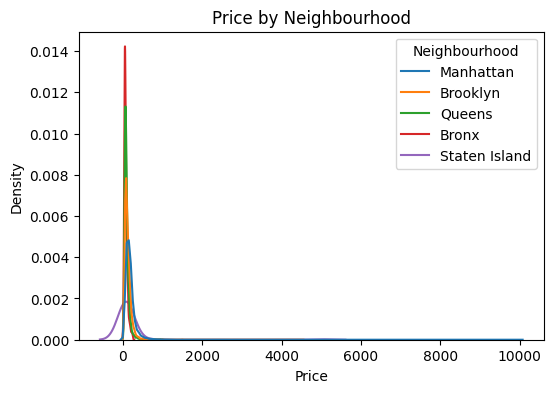

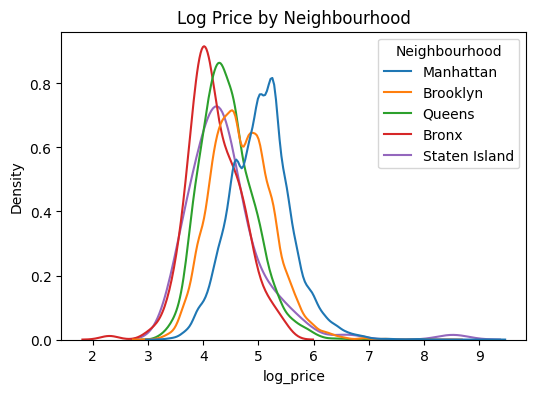

In [71]:
q1.columns = q1.columns.str.strip()
summary = q1.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
print(summary)
print("Most expensive borough on average:", summary["Price"].idxmax())

q1["log_price"] = np.log(q1["Price"])

plt.figure(figsize=(6,4))
sns.kdeplot(data=q1, x="Price", hue="Neighbourhood", common_norm=False)
plt.title("Price by Neighbourhood")
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(data=q1, x="log_price", hue="Neighbourhood", common_norm=False)
plt.title("Log Price by Neighbourhood")
plt.show()

Q2 2. I handled the dummy variable trap by dropping the first category. The conditional group means and the estimated coefficients have a positive linear relationship. A higher mean from part 1 resulted in a higher coefficient in part 2.

In [72]:
y = q1["Price"]

X = pd.get_dummies(q1["Neighbourhood"], drop_first=True)

model = LinearRegression().fit(X, y)

print(f"Model intercept: {model.intercept_}")
pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


Q2 3. A one point increase in review score rating changes price by 1.0208 (the slope).

In [73]:
X = q1[["Review Scores Rating"]]

model = LinearRegression().fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_[0]}")

Intercept: 60.878390657123546
Slope: 1.0208266022674763


Q2 4. The slope coefficient on review scores rating is now 1.0811, which is an increase from the earlier slope of 1.0208. Manhatten and Brooklyn had slight decreases in their coefficients, while Queens and Staten Island had slight increases in their coefficients.

In [74]:
X_neigh = pd.get_dummies(q1["Neighbourhood"], drop_first=True)
X = pd.concat([X_neigh, q1[["Review Scores Rating"]]], axis=1)

model = LinearRegression().fit(X, y)

print(f"Intercept: {model.intercept_}")
pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

Intercept: -23.812561011672244


,variable,coefficient
0,Brooklyn,51.704240
1,Manhattan,108.228737
2,Queens,21.694600
3,Staten Island,71.766552
4,Review Scores Rating,1.081116


Q2 5. The slopes are fairly similar for all neighborhoods except for Staten Island, which has a large interaction of -31.83.

In [75]:
X_neigh = pd.get_dummies(q1["Neighbourhood"], drop_first=True)
X = pd.concat([X_neigh, q1[["Review Scores Rating"]]], axis=1)

for col in X_neigh.columns:
    X[f"{col}_interaction"] = X_neigh[col] * q1["Review Scores Rating"]

model = LinearRegression().fit(X, y)

pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

,variable,coefficient
0,Brooklyn,-16.392990
1,Manhattan,41.315429
2,Queens,28.259701
3,Staten Island,2963.071040
4,Review Scores Rating,0.574311
5,Brooklyn_interaction,0.741165
6,Manhattan_interaction,0.729703
7,Queens_interaction,-0.072294
8,Staten Island_interaction,-31.831748


Q2 6. The model from part 4 was the most accurate, since it had the lowest MSE of 21070.

In [76]:
def cv_mse(X, y):
    model = LinearRegression()
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf)
    return -scores.mean()

X1 = pd.get_dummies(q1["Neighbourhood"], drop_first=True)
X2 = pd.concat([X1, q1[["Review Scores Rating"]]], axis=1)

X3 = X2.copy()
for col in X1.columns:
    X3[f"{col}_interaction"] = X1[col] * q1["Review Scores Rating"]

print(cv_mse(X1, y))
print(cv_mse(X2, y))
print(cv_mse(X3, y))

21155.008063004167
21070.810022391735
21323.158230682748


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


Q3 1. SUV is the most expensive car since it has the highest mean of 1.176495e+06. SUV is also the car with the most variance since it has the highest standard deviation of 417479.028217.

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


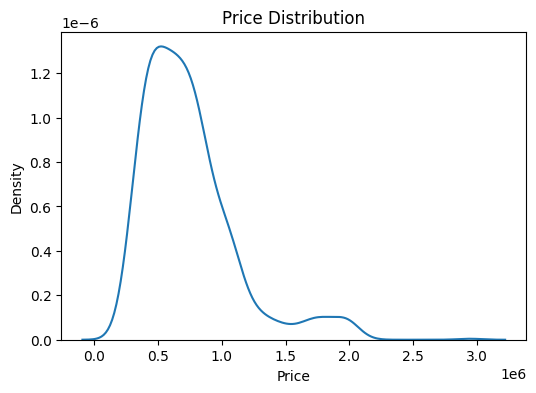

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


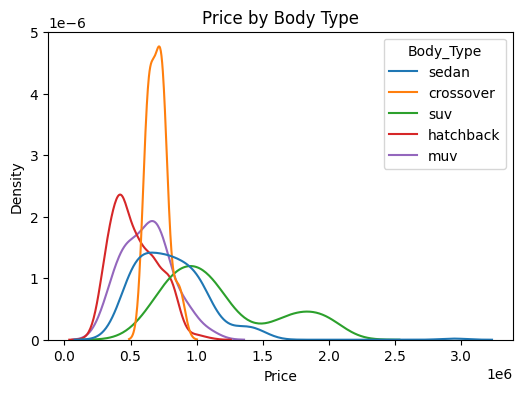

In [77]:
cars = pd.read_csv('./ds3001-linearmodels/data/cars_hw.csv')
cars.head()

print(cars["Price"].describe())

plt.figure(figsize=(6,4))
sns.kdeplot(data=cars, x="Price")
plt.title("Price Distribution")
plt.show()

print(cars.groupby("Body_Type")["Price"].describe())

plt.figure(figsize=(6,4))
sns.kdeplot(data=cars, x="Price", hue="Body_Type", common_norm=False)
plt.title("Price by Body Type")
plt.show()

Q3 2. Each additional seat changes the price by the slope amount of 59267.998. The price increases from 5 seats to 6 seats, but decreases from 6-8 seats.

In [78]:
y = cars["Price"]
X = cars[["Seating_Capacity"]]
model = LinearRegression().fit(X, y)
print(f"Slope: {model.coef_[0]}")

X = pd.get_dummies(cars["Seating_Capacity"], drop_first=True)
model = LinearRegression().fit(X, y)
pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

Slope: 59267.99803672175


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


Q3 3. The optimal number of powers of Age to include in a regression of Price on Age is 5 since it has the lowest MSE of 95265035514.25769.

In [79]:
cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]

X = cars[["Age"]]
y = cars["Price"]

for d in range(1,6):
    model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                          LinearRegression())

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf)

    print(d, -scores.mean())

1 97377248063.9968
2 97395705968.63509
3 96743204818.44325
4 96225038252.2612
5 95265035514.25769


Q3 4. Yes, the model accurately fits the patterns in the data.

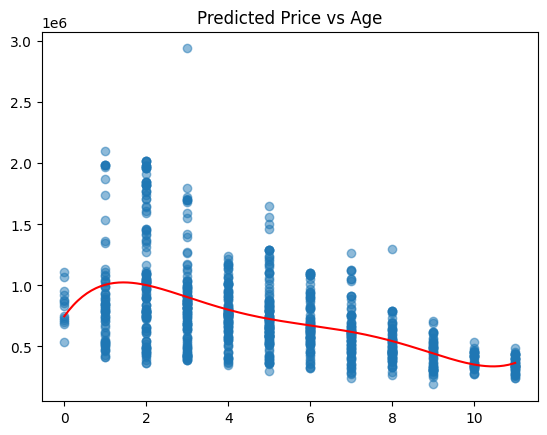

In [80]:
best_d = 5
model = make_pipeline(PolynomialFeatures(best_d, include_bias=False), LinearRegression())
model.fit(X, y)

age_grid = pd.DataFrame({"Age": np.linspace(cars["Age"].min(), cars["Age"].max(), 200)})
pred = model.predict(age_grid)

plt.scatter(cars["Age"], cars["Price"], alpha=0.5)
plt.plot(age_grid["Age"], pred, color='red')
plt.title("Predicted Price vs Age")
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


Q4 Load

In [81]:
heart = pd.read_csv('./ds3001-linearmodels/data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


Q4 1. The ATE on three-year survival for heart transplant interventions is 0.230179.

In [82]:
control = heart[heart["transplant"] == 'control']["y"].mean()
treatment = heart[heart["transplant"] == 'treatment']["y"].mean()

ate = treatment - control

print(f"Control: {control}")
print(f"Treatment: {treatment}")
print(f"ATE: {ate}")

Control: 0.11764705882352941
Treatment: 0.34782608695652173
ATE: 0.23017902813299232


Q4 2. The intercept is very similar to the control variable computed in part 1 and the coefficient is very similar to the ate variable computed in part 1.

In [83]:
heart["transplant_dummy"] = (heart["transplant"] == "treatment").astype(int)

X = heart[["transplant_dummy"]]
y = heart["y"]

model = LinearRegression().fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

Intercept: 0.1176470588235293
Coefficient: 0.23017902813299249


Q4 3. The coefficient on transplant changes by increasing from 0.2302 to 0.2647 after adjusting for age. The intercept represents the predicted survival probability for someone of age zero. The slope represents the difference in survival probability between treatment and control, holding age fixed. The ATE underestimates the impact of a transplant for ages under ~54 and overestimates the impact for ages over ~54.

Intercept: 0.7019569721740947
           variable  coefficient
0  transplant_dummy     0.264702
1               age    -0.013607


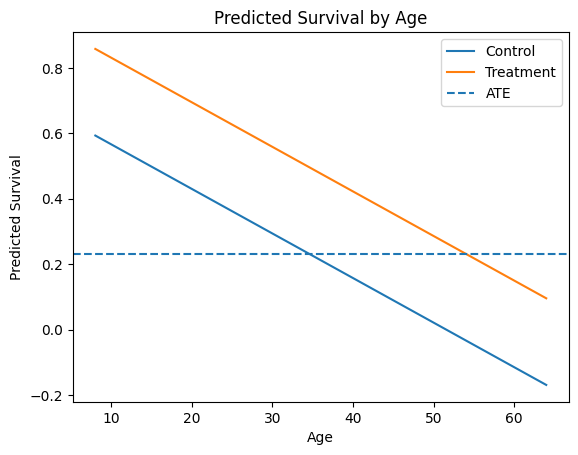

In [84]:
X = heart[["transplant_dummy", "age"]]
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_}")

r_ta = pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})
print(r_ta)

age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 100)

df0 = pd.DataFrame({
    "transplant_dummy": 0,
    "age": age_grid
})

df1 = pd.DataFrame({
    "transplant_dummy": 1,
    "age": age_grid
})

pred0 = model.predict(df0)
pred1 = model.predict(df1)

plt.plot(age_grid, pred0, label="Control")
plt.plot(age_grid, pred1, label="Treatment")

plt.axhline(ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.title("Predicted Survival by Age")
plt.show()

Q4 4. The coefficient on transplant changes by increasing from 0.2302 in part 1 to 0.9078 in part 4. The intercept represents the predicted survival probability for someone in the control group at age zero. The slope on transplant represents the effect of a transplant at age zero, while the interaction term represents how the treatment effect changes with age. The slope on age represents the effect of age on survival for the control group. The results show that the impact of a transplant is not constant and changes across ages, with the treatment effect decreasing as age increases. The ATE underestimates the impact of a transplant for ages under ~62.

Allowing age and transplant to interact results in a steeper slope for the effect of a transplant. This means that as age increases, the effect of a transplant decreases, which the model in part 3 does not account for.

Intercept: 0.35486517529945855
           variable  coefficient
0  transplant_dummy     0.907751
1               age    -0.005524
2       interaction    -0.014591


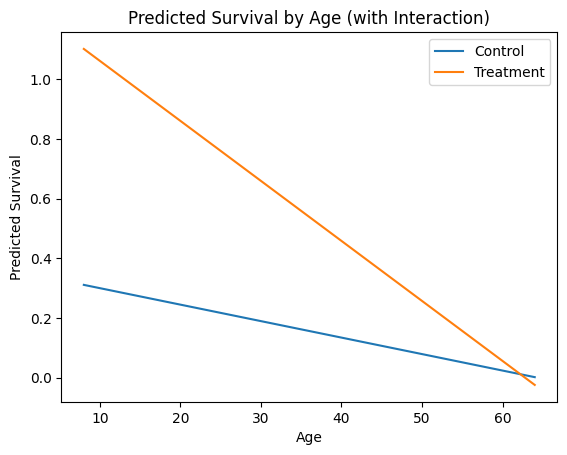

In [85]:
heart["interaction"] = heart["transplant_dummy"] * heart["age"]

X = heart[["transplant_dummy", "age", "interaction"]]
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_}")

r_ta = pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})
print(r_ta)

age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 100)

df0 = pd.DataFrame({
    "transplant_dummy": 0,
    "age": age_grid,
    "interaction": 0 * age_grid
})

df1 = pd.DataFrame({
    "transplant_dummy": 1,
    "age": age_grid,
    "interaction": 1 * age_grid
})

pred0 = model.predict(df0)
pred1 = model.predict(df1)

plt.plot(age_grid, pred0, label="Control")
plt.plot(age_grid, pred1, label="Treatment")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.title("Predicted Survival by Age (with Interaction)")
plt.show()

Q4 5. The best model was the model in part 4 since it had the lowest MSE of 0.1751. As we added more to our models in each part, the MSE decreases, meaning our model improved each time something was added to it.

In [86]:
X1 = heart[["transplant_dummy"]]
X2 = heart[["transplant_dummy", "age"]]
X3 = heart[["transplant_dummy", "age", "interaction"]]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for X in [X1, X2, X3]:
    scores = cross_val_score(LinearRegression(), X, y,
                             scoring="neg_mean_squared_error", cv=kf)
    print("MSE:", -scores.mean())

MSE: 0.1930687841733136
MSE: 0.1772665165855078
MSE: 0.17512042221989654


Q4 6. Observational data is used, which has not been randomized, meaning the results may not be causal. Patients receiving transplants have many other factors to consider other than just age. The model may unfairly prioritize certain age groups if used in actual practice. High-stakes medical decisions such as who should recieve a transplant requires more judgement than just a singular model.